# Preprocessing - life_style_data.duckdb

## Importation des librairies essentielles

In [495]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
from datetime import datetime
import json

import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.pipeline import Pipeline


import sqlite3


## Nettoyage des données

### Contexte & objectifs

Ce chapitre prépare le dataset life_style_data pour la modélisation.
Objectifs :
- Corriger les types (notamment les décimales avec virgules) ;
- Quantifier et traiter les valeurs manquantes ;
- Détecter/supprimer les doublons ;
- Poser des règles de plausibilité métier (sans censurer) ;
- Produire un rapport de nettoyage et des artefacts (dataset nettoyé).

Entrée : table DuckDB life_style_data (chargée via DBeaver).
Sorties : df_clean (Parquet/CSV), tableaux de suivi (manquants, conversions, doublons, flags).

### Imports, paramètres, chargement depuis DuckDB

In [496]:
# Définition des chemins (adaptés à ton arborescence GitHub)
# Notebook : C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks\preprocessing\life_style_data
# Base     : C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\raw\life_style_data

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Chemins complets
db_path = project_root / "src" / "data" / "raw" / "life_style_data" / "life_style_data"
export_dir = project_root / "src" / "data" / "processed" / "life_style_data"
model_dir = project_root / "src" / "models" / "v1" / "life_style_data"

# Connexion à la base DuckDB
con = duckdb.connect(str(db_path))
# Connexion SQLite
con_sqlite = sqlite3.connect(export_dir / "life_style_data_val.db")

# Chargement de la table
df = con.execute("SELECT * FROM life_style_data").fetchdf()

# Extraire les 10 premières lignes
df_sample = df.head(10).copy()
df = df.iloc[10:].reset_index(drop=True)

# Écriture du sample dans la base SQLite
table_name = "sample"
df_sample.to_sql(table_name, con_sqlite, if_exists="replace", index=False)

print(f"✔ Échantillon extrait : {df_sample.shape[0]} lignes")
print(f"✔ Données restantes  : {df.shape[0]} lignes")

# Vérification du chargement
shape_before = df.shape
print(f"✔ Données chargées : {shape_before[0]} lignes, {shape_before[1]} colonnes")
display(df.head(3))

✔ Échantillon extrait : 10 lignes
✔ Données restantes  : 19990 lignes
✔ Données chargées : 19990 lignes, 54 colonnes


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,50.51,Male,86.37,1.63,160.92,143.20,57.87,1.69,1974.26,Strength,...,2065.28,0.501588,1.189302,0.828045,0.889883,501.74,61.260921,1203.9560,9.983135e+19,High
1,47.77,Female,83.89,1.82,176.36,148.74,69.91,1.91,2733.40,HIIT,...,1848.79,0.500133,1.111813,0.740535,0.843389,-501.40,64.050587,1379.5166,1.116947e+20,Very High
2,19.00,Male,82.66,1.96,173.75,168.71,62.16,1.89,2700.62,HIIT,...,1446.67,0.502727,0.866199,0.954835,0.970993,-131.62,62.715145,1353.0888,1.039329e+20,High


### Audit qualité initial

On dresse un état des lieux :
- Répartition des types et cardinalités ;
- Valeurs manquantes (%) par colonne ;
- Doublons potentiels.

Cet instantané nous sert de référence avant toute modification.

In [497]:
# Audit qualité initial
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
dup_count = df.duplicated().sum()

summary_types = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing_%": df.isna().mean() * 100
}).sort_values("missing_%", ascending=False)

print(f"• Doublons détectés (avant): {dup_count}")
display(missing_pct.to_frame("missing_%").head(20))
display(summary_types.head(20))


• Doublons détectés (avant): 0


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


,dtype,n_unique,missing_%
Age,float64,3950,0.0
Body Part,object,7,0.0
prep_time_min,float64,5384,0.0
cook_time_min,float64,9405,0.0
rating,float64,414,0.0
Name of Exercise,object,55,0.0
Sets,float64,30,0.0
Reps,float64,654,0.0
Benefit,object,49,0.0
Burns Calories (per 30 min),float64,5765,0.0


### Correction de types (décimales à virgule, espaces insécables)

Dans de nombreux exports, les colonnes numériques arrivent en texte (object) avec :
- des virgules à la place du point décimal ;
- des espaces insécables (\u00A0) ou espaces.

On corrige proprement pour garantir la cohérence numérique.

In [498]:
# Conversion robuste des colonnes numériques candidates (si présentes)
num_candidates = [
    "Age","Weight (kg)","Height (m)","Max_BPM","Avg_BPM","Resting_BPM",
    "Session_Duration (hours)","Fat_Percentage","Water_Intake (liters)",
    "Workout_Frequency (days/week)","BMI","Carbs","Proteins","Fats","Calories",
    "sugar_g","sodium_mg","cholesterol_mg","serving_size_g","prep_time_min","cook_time_min",
    "rating","BMI_calc","cal_from_macros","pct_carbs","protein_per_kg","pct_HRR","pct_maxHR",
    "cal_balance","lean_mass_kg","expected_burn","Burns Calories (per 30 min)","Calories_Burned"
]

convert_log = []
df_conv = df.copy()

for c in [col for col in num_candidates if col in df_conv.columns]:
    if df_conv[c].dtype == "object":
        before_na = df_conv[c].isna().sum()
        df_conv[c] = (df_conv[c]
            .astype(str)
            .str.replace(",", ".", regex=False)     # virgule ⇒ point
            .str.replace("\u00A0", "", regex=False) # espace insécable
            .str.strip()
        )
        df_conv[c] = pd.to_numeric(df_conv[c], errors="coerce")
        after_na = df_conv[c].isna().sum()
        convert_log.append({"column": c, "was_object": True, "na_before": before_na, "na_after": after_na})

convert_report = pd.DataFrame(convert_log).sort_values("column") if convert_log else pd.DataFrame(columns=["column","was_object","na_before","na_after"])
display(convert_report)


,column,was_object,na_before,na_after


### Règles de plausibilité (flags non bloquants)

On applique des bornes métier pour repérer des valeurs possiblement aberrantes.
On ne supprime pas : on flague pour informer la modélisation et documenter les décisions.

Exemples (paramétrables) :
- Age ∈ [10, 90]
- Max_BPM ∈ [80, 230]
- Session_Duration (hours) ∈ [0.1, 6]
- BMI ∈ [10, 60]

In [499]:
# 1.4 Flags de plausibilité (ne supprime rien)
df_flag = df_conv.copy()

def safe_between(s, low, high):
    return s.between(low, high) if s.notna().any() else pd.Series(False, index=s.index)

flags = {}
if "Age" in df_flag:               flags["Age_out"] = ~safe_between(df_flag["Age"], 10, 90)
if "Max_BPM" in df_flag:           flags["BPM_out"] = ~safe_between(df_flag["Max_BPM"], 80, 230)
if "Session_Duration (hours)" in df_flag: flags["SessDur_out"] = ~safe_between(df_flag["Session_Duration (hours)"], 0.1, 6)
if "BMI" in df_flag:               flags["BMI_out"] = ~safe_between(df_flag["BMI"], 10, 60)

flag_counts = {k: v.fillna(False).sum() for k, v in flags.items()}
flag_table = pd.DataFrame.from_dict(flag_counts, orient="index", columns=["nb_outliers"]).sort_index()
display(flag_table)


,nb_outliers
Age_out,0
BMI_out,0
BPM_out,0
SessDur_out,0


### Imputation des valeurs manquantes (baseline)

Stratégie simple et robuste (baseline reproductible) :
- Numériques → médiane (moins sensible aux outliers) ;
- Catégorielles → mode (valeur la plus fréquente, sinon “Unknown”).

Cette baseline est suffisante pour itérer ; on pourra spécialiser par la suite.

In [500]:
# 1.5 Imputation des manquants
df_imp = df_flag.copy()

num_cols = df_imp.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df_imp.columns if c not in num_cols]

# Numériques → médiane
for c in num_cols:
    if df_imp[c].isna().any():
        df_imp[c] = df_imp[c].fillna(df_imp[c].median())

# Catégorielles → mode (ou "Unknown")
for c in cat_cols:
    if df_imp[c].isna().any():
        m = df_imp[c].mode(dropna=True)
        df_imp[c] = df_imp[c].fillna(m.iloc[0] if not m.empty else "Unknown")

missing_before = missing_pct  # gardé depuis 1.2
missing_after = df_imp.isna().mean().sort_values(ascending=False) * 100

print("✔ Imputation effectuée.")
display(pd.DataFrame({"missing_before_%": missing_before}).head(10))
display(pd.DataFrame({"missing_after_%": missing_after}).head(10))


✔ Imputation effectuée.


,missing_before_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


,missing_after_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0


### Doublons & incohérences simples

On élimine les doublons stricts (lignes identiques).

Cette opération stabilise la taille du corpus et évite des biais à l’entraînement.

In [501]:
# 1.6 Doublons
rows_before = df_imp.shape[0]
dup_total = df_imp.duplicated().sum()
df_clean = df_imp.drop_duplicates().reset_index(drop=True)
rows_after = df_clean.shape[0]

clean_report = pd.DataFrame({
    "rows_before":[rows_before],
    "rows_after":[rows_after],
    "duplicates_removed":[dup_total],
    "cols":[df_clean.shape[1]]
})
display(clean_report)


,rows_before,rows_after,duplicates_removed,cols
0,19990,19990,0,54


### Rapport de nettoyage (synthèse consultant)

Nous consolidons les éléments clés pour traçabilité et communication :
- Colonnes converties object → numeric ;
- Avant/Après des valeurs manquantes ;
- Nombre de doublons supprimés ;
- Flags de plausibilité relevés.

Ce rapport sert de référence pour justifier les choix et préparer la suite (encodage, scaling).

In [502]:
# 1.7 Rapport consolidé
sections = {
    "convert_report": convert_report,
    "missing_before_% (top 20)": missing_before.to_frame("missing_%").head(20),
    "missing_after_% (top 20)": missing_after.to_frame("missing_%").head(20),
    "plausibility_flags": flag_table,
    "clean_report": clean_report
}

for title, df_sec in sections.items():
    print("\n" + "="*30 + f" {title} " + "="*30)
    display(df_sec)



============================== convert_report ==============================


,column,was_object,na_before,na_after



============================== missing_before_% (top 20) ==============================


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0



============================== missing_after_% (top 20) ==============================


,missing_%
Age,0.0
Body Part,0.0
prep_time_min,0.0
cook_time_min,0.0
rating,0.0
Name of Exercise,0.0
Sets,0.0
Reps,0.0
Benefit,0.0
Burns Calories (per 30 min),0.0



============================== plausibility_flags ==============================


,nb_outliers
Age_out,0
BMI_out,0
BPM_out,0
SessDur_out,0



============================== clean_report ==============================


,rows_before,rows_after,duplicates_removed,cols
0,19990,19990,0,54


### Export des artefacts (dataset nettoyé)

On persiste le dataset nettoyé pour les étapes suivantes (encodage, scaling, split) et pour reproductibilité :
- life_style_data_clean.parquet (format recommandé) ;
- Optionnel : life_style_data_clean.csv.

In [503]:
# 1.8 Export artefacts
parquet_path = export_dir / "life_style_data_clean.parquet"
# csv_path     = export_dir / "life_style_data_clean.csv"

df_clean.to_parquet(parquet_path, index=False, engine="fastparquet")
# df_clean.to_csv(csv_path, index=False)

print(f"✔ Export parquet : {parquet_path}")
# print(f"✔ Export csv     : {csv_path}")
print(f"✔ Shape final    : {df_clean.shape}")


✔ Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_clean.parquet
✔ Shape final    : (19990, 54)


### Définition des champs métier pour l'entrainement

In [504]:
# Charger les artefacts nettoyés
df_features = pd.read_parquet(parquet_path)

print(f"✔ Dataset chargé : {df_features.shape[0]} lignes, {df_features.shape[1]} colonnes")
df_features.head(3)

# Filtrer uniquement les features "métier" retenues
# selected_features = [
#     # Prédiction target
#     "Calories_Burned",

#     # Core
#     "Age", "Gender", "Weight (kg)", "Max_BPM", "Avg_BPM", "Resting_BPM",
#     "Session_Duration (hours)", "Workout_Type", "Experience_Level",
#     "Difficulty Level", "Body Part", "Equipment Needed",
#     "Workout_Frequency (days/week)", "Water_Intake (liters)",
#     "Fat_Percentage", "diet_type", "meal_type",

#     # Nutrition
#     "Calories", "Carbs", "Proteins", "Fats",

#     # Optionnels (si présents dans ton dataset)
#     "BMI", "sugar_g", "sodium_mg", "cholesterol_mg", "serving_size_g",
#     "Name of Exercise", "Sets", "Reps", "Target Muscle Group",
#     "Type of Muscle", "Benefit", "rating",
#     "cooking_method", "prep_time_min", "cook_time_min"
# ]
selected_features = [
    # Prédiction target
    "Calories_Burned",

    # Core
    "Age", "Weight (kg)"
]


# Vérifier quelles colonnes sont présentes dans le DataFrame
print(df_features.columns)
existing_features = [col for col in selected_features if col in df_features.columns]
missing_features = [col for col in selected_features if col not in df_features.columns]

# Filtrage du DataFrame sur les colonnes existantes
df_features = df_features[existing_features]

print(f"✔ Colonnes conservées : {len(existing_features)}")
if missing_features:
    print(f"⚠️ Colonnes absentes du dataset : {missing_features}")


parquet_path = export_dir / "life_style_data_feature.parquet"
df_features.to_parquet(parquet_path, index=False, engine="fastparquet")
# df_clean.to_csv(csv_path, index=False)

print(f"✔ Export parquet : {parquet_path}")
# print(f"✔ Export csv     : {csv_path}")
print(f"✔ Shape final    : {df_clean.shape}")

✔ Dataset chargé : 19990 lignes, 54 colonnes
Index(['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)',
       'Workout_Frequency (days/week)', 'Experience_Level', 'BMI',
       'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name of Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group',
       'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn',
       'Burns Calories (per 30 min)_bc', 'Burns_Calories_

### Critères d’acceptation & décisions

- Types numériques/catégoriels conformes au dictionnaire ;
- Manquants résiduels documentés et ≤ seuils tolérés (par défaut, 5%) ;
- Doublons supprimés (ou chiffrés et justifiés si conservés) ;
- Flags de plausibilité suivis (pas de censure sans décision métier explicite).

Décisions à garder au journal :
- Colonnes converties, colonnes fortement manquantes et stratégie appliquée ;
- Seuils de plausibilité retenus et impact (aucune ligne supprimée à ce stade) ;
- Lieux d’export des artefacts.

## Encodage des variables catégorielles

### Objectifs

Cette étape consiste à transformer les variables catégorielles du jeu de données nettoyé en représentations numériques exploitables par les algorithmes de Machine Learning.
L’encodage rend les colonnes qualitatives compatibles avec les modèles tout en préservant l’information sémantique.
Deux approches principales sont appliquées selon la nature des catégories :
- Encodage ordinal pour les variables hiérarchiques (ex. niveau d’expérience) ;
- Encodage one-hot pour les variables nominales (ex. type d’exercice, partie du corps, équipement).

### Chargement du dataset nettoyé

In [505]:
# Charger les artefacts nettoyés
df_clean = pd.read_parquet(parquet_path)

print(f"✔ Dataset chargé : {df_clean.shape[0]} lignes, {df_clean.shape[1]} colonnes")
df_clean.head(3)

✔ Dataset chargé : 19990 lignes, 3 colonnes


,Calories_Burned,Age,Weight (kg)
0,1974.26,50.51,86.37
1,2733.40,47.77,83.89
2,2700.62,19.00,82.66


### Identification des variables catégorielles
On repère les variables non numériques à encoder.
L’objectif est de distinguer :
- les variables nominales (non ordonnées),
- les variables ordinales (possédant une hiérarchie logique).

In [506]:
# Identification des colonnes catégorielles
cat_cols = df_clean.select_dtypes(exclude=["number"]).columns.tolist()
print(f"🔎 {len(cat_cols)} variables catégorielles détectées :")
cat_cols


🔎 0 variables catégorielles détectées :


[]

### Encodage ordinal

Les variables catégorielles ordonnées (par ex. Experience_Level, Difficulty Level) sont converties en valeurs entières selon leur progression logique.

Cette méthode conserve la hiérarchie implicite entre les modalités.

In [507]:
# # Encodage ordinal sur variables à hiérarchie logique
# ordinal_features = ["Experience_Level", "Difficulty Level"]

# encoder_ordinal = OrdinalEncoder()
# df_clean[ordinal_features] = encoder_ordinal.fit_transform(df_clean[ordinal_features])

# print("✔ Encodage ordinal appliqué sur :", ordinal_features)
# df_clean[ordinal_features].head()


### Encodage One-Hot

Les variables nominales (sans hiérarchie) sont transformées par One-Hot Encoding, créant une colonne binaire par modalité.

Cela permet d’éviter toute interprétation de relation d’ordre entre catégories.

In [508]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=[col for col in cat_cols if col not in ["Experience_Level", "Difficulty Level"]],
    drop_first=True
)

print(f"✔ One-Hot Encoding appliqué : {df_encoded.shape[1]} colonnes au total")
df_encoded.head(3)


✔ One-Hot Encoding appliqué : 3 colonnes au total


,Calories_Burned,Age,Weight (kg)
0,1974.26,50.51,86.37
1,2733.40,47.77,83.89
2,2700.62,19.00,82.66


### Vérification post-encodage

Après encodage :
- Toutes les variables sont numériques ;
- Le nombre de colonnes augmente (selon le nombre de modalités) ;
- Aucun NaN ne doit être réintroduit.

In [509]:
print(f"Forme finale du dataset encodé : {df_encoded.shape}")
print(f"Valeurs manquantes totales : {df_encoded.isna().sum().sum()}")

# Aperçu d'un sous-ensemble des nouvelles colonnes encodées
df_encoded.filter(like="Workout_Type").head(5)


Forme finale du dataset encodé : (19990, 3)
Valeurs manquantes totales : 0


""
0
1
2
3
4


### Export du dataset encodé

On exporte le jeu de données final encodé pour les étapes suivantes :
- Mise à l’échelle / normalisation
- Split train/test

In [510]:
encoded_path = export_dir / "life_style_data_encoded.parquet"
df_encoded.to_parquet(encoded_path, index=False)
print(f"✔ Export du dataset encodé : {encoded_path}")


✔ Export du dataset encodé : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_encoded.parquet


L’encodage garantit la compatibilité du jeu de données avec les algorithmes de Machine Learning.

Les variables catégorielles hiérarchiques ont été traitées par encodage ordinal, et les variables nominales par encodage one-hot, réduisant les risques de biais d’interprétation.

## Mise à l’échelle / Normalisation des variables numériques

### Objectifs

Cette étape vise à homogénéiser les échelles des variables numériques afin d’éviter qu’une variable à grande amplitude (ex. Calories ou Weight (kg)) ne domine les autres lors de l’apprentissage du modèle.
Deux techniques sont généralement utilisées :
- StandardScaler : recentre les données autour de 0 et réduit leur variance à 1 ;
- MinMaxScaler : ramène les valeurs dans un intervalle [0,1].

Le choix du scaler dépend de la nature des modèles :
- Les algorithmes linéaires ou ceux utilisant une distance (SVM, KNN, PCA) sont sensibles à l’échelle → StandardScaler privilégié ;
- Les modèles arborescents (Random Forest, XGBoost) y sont peu sensibles.

In [511]:
encoded_path = export_dir / "life_style_data_encoded.parquet"

df_encoded = pd.read_parquet(encoded_path)
print(f"✔ Dataset encodé chargé : {df_encoded.shape[0]} lignes, {df_encoded.shape[1]} colonnes")
df_encoded.head(3)

✔ Dataset encodé chargé : 19990 lignes, 3 colonnes


,Calories_Burned,Age,Weight (kg)
0,1974.26,50.51,86.37
1,2733.40,47.77,83.89
2,2700.62,19.00,82.66


### Sélection des variables numériques

On identifie toutes les variables numériques du dataset afin d’appliquer la mise à l’échelle uniquement sur celles qui ne sont pas déjà binaires (0/1).

Les colonnes issues du One-Hot Encoding ne doivent pas être modifiées.

In [512]:
# Identifier toutes les colonnes numériques
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les colonnes binaires (issues du One-Hot Encoding)
non_binary_num_cols = [col for col in num_cols if df_encoded[col].nunique() > 2]

print(f"🔎 Variables numériques à mettre à l’échelle : {len(non_binary_num_cols)}")
non_binary_num_cols[:15]  # aperçu

🔎 Variables numériques à mettre à l’échelle : 3


['Calories_Burned', 'Age', 'Weight (kg)']

### Application du StandardScaler

Le StandardScaler est appliqué sur toutes les variables continues identifiées.

Cette normalisation rend la moyenne nulle et la variance unitaire, garantissant un traitement équilibré par les algorithmes sensibles à l’échelle des features.

In [513]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_encoded[non_binary_num_cols])

# Remplacer les colonnes originales par leurs versions normalisées
df_scaled = df_encoded.copy()
df_scaled[non_binary_num_cols] = scaled_values

print("✔ Standardisation terminée.")
df_scaled[non_binary_num_cols].describe().T.head(10)

✔ Standardisation terminée.


,count,mean,std,min,25%,50%,75%,max
Calories_Burned,19990.0,-1.094783e-16,1.000025,-1.905592,-0.735383,-0.096486,0.543406,3.207234
Age,19990.0,1.206750e-16,1.000025,-1.721249,-0.881770,0.084003,0.889639,1.718387
Weight (kg),19990.0,1.597744e-16,1.000025,-1.639784,-0.743384,-0.184197,0.576066,2.685888


### Vérification post-normalisation

Après mise à l’échelle :
- La moyenne des colonnes est proche de 0 ;
- L’écart-type est proche de 1 ;
- Les colonnes binaires n’ont pas été modifiées.

In [514]:
# Vérification moyenne ~0 et std ~1
check_stats = df_scaled[non_binary_num_cols].agg(["mean", "std"]).T
check_stats.head(10)

,mean,std
Calories_Burned,-1.094783e-16,1.000025
Age,1.206750e-16,1.000025
Weight (kg),1.597744e-16,1.000025


### Export du dataset normalisé

Le dataset final normalisé est sauvegardé pour la suite du pipeline :
- life_style_data_scaled.parquet : pour la modélisation supervisée ;
- life_style_data_scaled.csv : pour inspection rapide sous DBeaver.

In [515]:
scaled_path = export_dir / "life_style_data_scaled.parquet"
# csv_scaled_path = export_dir / "life_style_data_scaled.csv"

df_scaled.to_parquet(scaled_path, index=False)
# df_scaled.to_csv(csv_scaled_path, index=False)

print(f"✔ Export parquet : {scaled_path}")
# print(f"✔ Export csv     : {csv_scaled_path}")
print(f"✔ Shape final    : {df_scaled.shape}")

✔ Export parquet : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\life_style_data_scaled.parquet
✔ Shape final    : (19990, 3)


Critères de validation :
- Moyenne ≈ 0 et écart-type ≈ 1 pour les colonnes normalisées ;
- Aucune valeur manquante ou anormale après transformation ;
- Colonnes binaires conservées inchangées ;
- Fichiers d’export générés sans perte de structure.

Cette étape garantit une échelle cohérente entre toutes les variables continues, assurant un apprentissage plus stable et une meilleure convergence lors de la modélisation.

## Séparation features/target et split en jeux d’entraînement et de test

### Objectif

L’objectif de cette étape est de préparer les données d’apprentissage en distinguant :
- les features (X) : variables explicatives,
- la target (y) : variable cible à prédire.

Le jeu de données est ensuite découpé en deux sous-ensembles :
- Jeu d’entraînement (train set) : pour ajuster les paramètres du modèle (généralement 80 %) ;
- Jeu de test (test set) : pour évaluer sa capacité de généralisation (généralement 20 %).

Cette séparation est une pratique fondamentale du Machine Learning supervisé, garantissant la fiabilité de l’évaluation des performances.

In [516]:
scaled_path = export_dir / "life_style_data_scaled.parquet"

# df_scaled = pd.read_parquet(scaled_path)
df_scaled = df_clean

print(f"✔ Dataset normalisé chargé : {df_scaled.shape[0]} lignes, {df_scaled.shape[1]} colonnes")
df_scaled.head(3)

✔ Dataset normalisé chargé : 19990 lignes, 3 colonnes


,Calories_Burned,Age,Weight (kg)
0,1974.26,50.51,86.37
1,2733.40,47.77,83.89
2,2700.62,19.00,82.66


### Définition de la variable cible

La variable à prédire dans ce projet est Calories_Burned (y_calories_burned dans la table).

Elle représente la dépense calorique totale estimée selon les caractéristiques physiques et comportementales de l’utilisateur.

Toutes les autres colonnes servent de features (X).

In [517]:
# Identifier la colonne cible
# target_col = "y_calories_burned"
target_col = "Calories_Burned"

# Vérification que la variable existe bien
assert target_col in df_scaled.columns, f"La colonne cible {target_col} est introuvable."

# Séparation X (features) / y (target)
X = df_scaled.drop(columns=[target_col])
y = df_scaled[target_col]

print(f"✔ Features (X) : {X.shape[1]} colonnes")
print(f"✔ Target (y)   : {y.name}")

✔ Features (X) : 2 colonnes
✔ Target (y)   : Calories_Burned


### Split train/test/val

Le split est effectué avec un ratio suivant :
- Train (70 %) → apprentissage des poids du modèle
- Validation (15 %) → sélection des hyperparamètres et early stopping
- Test (15 %) → évaluation finale, non touché avant la fin du projet

In [518]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42)  # 0.1765 × 0.85 ≈ 0.15

print(f"✔ Jeu d’entraînement : {X_train.shape}")
print(f"✔ Jeu de test        : {X_test.shape}")
print(f"✔ Jeu de validation  : {X_val.shape}")

✔ Jeu d’entraînement : (13992, 2)
✔ Jeu de test        : (2999, 2)
✔ Jeu de validation  : (2999, 2)


### Vérification statistique du split

On vérifie que :
- les proportions sont respectées (80/20),
- la distribution statistique de la variable cible reste similaire entre les deux sous-ensembles (absence de biais de séparation).

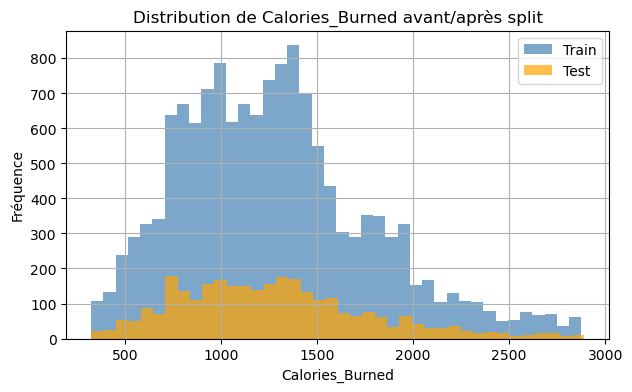

Train mean: 1279.90, Test mean: 1272.84


In [519]:
plt.figure(figsize=(7,4))
plt.hist(y_train, bins=40, alpha=0.7, label="Train", color="steelblue")
plt.hist(y_test, bins=40, alpha=0.7, label="Test", color="orange")
plt.legend()
plt.title("Distribution de Calories_Burned avant/après split")
plt.xlabel("Calories_Burned")
plt.ylabel("Fréquence")
plt.grid(True)
plt.show()

print(f"Train mean: {y_train.mean():.2f}, Test mean: {y_test.mean():.2f}")

### Export des sous-ensembles

Les quatre sous-ensembles sont sauvegardés sous format Parquet, prêts à être utilisés pour l’entraînement et la validation des modèles.

In [520]:
X_train.to_parquet(export_dir / "X_train.parquet", index=False)
X_test.to_parquet(export_dir / "X_test.parquet", index=False)
X_val.to_parquet(export_dir / "X_val.parquet", index=False)
y_train.to_frame().to_parquet(export_dir / "y_train.parquet", index=False)
y_test.to_frame().to_parquet(export_dir / "y_test.parquet", index=False)
y_val.to_frame().to_parquet(export_dir / "y_val.parquet", index=False)

print("✔ Export des sous-ensembles effectué avec succès.")

✔ Export des sous-ensembles effectué avec succès.


Synthèse & critères d’acceptation :
- La variable cible Calories_Burned est correctement isolée.
- Les proportions de split sont respectées (≈ 80 % / 20 %).
- Les distributions train/test sont similaires → absence de biais de sélection.
- Les fichiers Parquet exportés garantissent la traçabilité et la reproductibilité du pipeline.

Cette étape finalise la préparation des données d’apprentissage, assurant une séparation claire entre entraînement et évaluation.

Elle constitue la base du bloc 5 — Feature Engineering et de l’entraînement des modèles supervisés.

## Sélection ou création de features pertinentes

### Objectif

Cette étape vise à optimiser la qualité des variables utilisées pour la modélisation, en éliminant les features redondantes ou peu informatives et en créant de nouvelles variables plus représentatives du phénomène étudié.

Deux approches sont utilisées :
- Sélection de features : identification des variables les plus corrélées à la cible (feature importance).
- Création de nouvelles features : dérivées ou combinaisons logiques des variables existantes (ratios, interactions, indicateurs composites).

In [521]:
X_train = pd.read_parquet(export_dir / "X_train.parquet")
X_test  = pd.read_parquet(export_dir / "X_test.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()  # conversion en Series
y_test  = pd.read_parquet(export_dir / "y_test.parquet").squeeze() # conversion en Series


print(f"✔ Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"✔ Données chargées : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")

✔ Données chargées : 13992 lignes, 2 colonnes
✔ Données chargées : 2999 lignes, 2 colonnes

✔ Données chargées : 2999 lignes, 2 colonnes


### Analyse de corrélation et importance des variables

On commence par une analyse de corrélation entre les variables numériques et la cible.

Cette étape permet de repérer les variables les plus influentes sur Calories_Burned.

Une méthode complémentaire basée sur un modèle de RandomForestRegressor est utilisée pour estimer l’importance relative des features.

In [522]:
# # Calcul des corrélations (variables continues uniquement)
# corr = X_train.corrwith(y_train).dropna().sort_values(ascending=False)
# top_corr = corr.head(10)

# plt.figure(figsize=(8,4))
# top_corr.plot(kind="bar", color="steelblue")
# plt.title("Corrélation des 10 variables les plus liées à Calories_Burned")
# plt.ylabel("Coefficient de corrélation")
# plt.grid(True, axis='y')
# plt.show()

# # Modèle RandomForest pour importance des features
# model_rf = RandomForestRegressor(random_state=42, n_estimators=100)
# model_rf.fit(X_train, y_train)

# importances = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
# top_importances = importances.head(10)

# plt.figure(figsize=(8,4))
# top_importances.plot(kind="bar", color="orange")
# plt.title("Top 10 - Importance des variables (RandomForest)")
# plt.ylabel("Importance relative")
# plt.grid(True, axis='y')
# plt.show()

### Création de nouvelles features

Certaines combinaisons de variables améliorent la capacité prédictive.

On crée ici plusieurs variables dérivées liées à la physiologie et à l’activité physique :
- BPM_effort_ratio = Avg_BPM / Max_BPM
- Fat_to_weight_ratio = Fat_Percentage / Weight (kg)
- Workout_intensity = Calories_Burned / Session_Duration (hours) (proxy de rendement énergétique)
- Hydration_ratio = Water_Intake (liters) / Workout_Frequency (days/week)

In [523]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Ratios cardio
    if {"Avg_BPM", "Max_BPM"}.issubset(df.columns):
        df["BPM_effort_ratio"] = df["Avg_BPM"] / (df["Max_BPM"].replace(0, np.nan))
    # Composition corporelle
    if {"Fat_Percentage", "Weight (kg)"}.issubset(df.columns):
        df["Fat_to_weight_ratio"] = df["Fat_Percentage"] / (df["Weight (kg)"].replace(0, np.nan))
    # Hydratation relative
    if {"Water_Intake (liters)", "Workout_Frequency (days/week)"}.issubset(df.columns):
        df["Hydration_ratio"] = df["Water_Intake (liters)"] / (df["Workout_Frequency (days/week)"] + 1e-3)
    # Nettoyage inf/NaN générés par divisions
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)
    return df

### Réduction des features redondantes

Certaines variables peuvent être fortement corrélées entre elles, ce qui nuit à la stabilité du modèle.

On applique un filtrage basé sur la matrice de corrélation et un seuil de tolérance pour supprimer les doublons d’information.

In [524]:
# 2.2 Appliquer EXACTEMENT les mêmes features aux deux
X_train_fe = create_features(X_train)
X_test_fe  = create_features(X_test)
X_val_fe  = create_features(X_val)

# corr_matrix = X_train_fe.corr().abs()
# upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# to_drop = [c for c in upper_tri.columns if any(upper_tri[c] > 0.95)]

print(f"🧹 Variables supprimées pour corrélation élevée (>0.95) : {len(to_drop)}")
X_train_reduced = X_train_fe.drop(columns=to_drop, errors="ignore")
X_test_reduced = X_test_fe.drop(columns=to_drop, errors="ignore")
X_val_reduced = X_test_fe.drop(columns=to_drop, errors="ignore")


🧹 Variables supprimées pour corrélation élevée (>0.95) : 0


### Export des nouvelles données

On sauvegarde le dataset enrichi et allégé pour les étapes suivantes de modélisation supervisée.

In [525]:
feature_path = export_dir / "X_train_feature_engineered.parquet"
X_train_reduced.to_parquet(feature_path, index=False)

print(f"✔ Export du jeu de données enrichi : {feature_path}")
print(f"✔ Nombre final de colonnes : {X_train_reduced.shape[1]}")

feature_path = export_dir / "X_test_feature_engineered.parquet"
X_test_reduced.to_parquet(feature_path, index=False)

print(f"✔ Export du jeu de données enrichi : {feature_path}")
print(f"✔ Nombre final de colonnes : {X_test_reduced.shape[1]}")

feature_path = export_dir / "X_val_feature_engineered.parquet"
X_val_reduced.to_parquet(feature_path, index=False)

print(f"✔ Export du jeu de données enrichi : {feature_path}")
print(f"✔ Nombre final de colonnes : {X_val_reduced.shape[1]}")


✔ Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_train_feature_engineered.parquet
✔ Nombre final de colonnes : 2
✔ Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_test_feature_engineered.parquet
✔ Nombre final de colonnes : 2
✔ Export du jeu de données enrichi : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\data\processed\life_style_data\X_val_feature_engineered.parquet
✔ Nombre final de colonnes : 2


Critères de validation :
- Identification claire des variables les plus influentes sur la cible ;
- Création de nouvelles variables pertinentes et explicables ;
- Suppression des redondances au-delà d’un seuil de corrélation de 0.95 ;
- Aucune valeur manquante introduite lors des transformations.

Cette étape améliore la qualité informationnelle du dataset et prépare le terrain pour la phase 6 – Choix et entraînement du modèle supervisé.

## Choix du modèle d’apprentissage supervisé

### Objectif

L’objectif de cette section est de sélectionner et d’entraîner un ou plusieurs modèles supervisés afin de prédire la variable cible Calories_Burned à partir des variables explicatives sélectionnées.

Plusieurs algorithmes seront comparés selon leurs performances et leurs caractéristiques :
- Régression linéaire : modèle de base simple, interprétable et rapide ;
- Random Forest Regressor : modèle non linéaire, robuste et performant sur des données hétérogènes ;
- Gradient Boosting Regressor : modèle plus complexe, souvent plus précis mais plus coûteux en calcul.

In [526]:
X_train = pd.read_parquet(export_dir / "X_train_feature_engineered.parquet")
y_train = pd.read_parquet(export_dir / "y_train.parquet").squeeze()
X_test = pd.read_parquet(export_dir / "X_test_feature_engineered.parquet")
y_test = pd.read_parquet(export_dir / "y_test.parquet").squeeze()
X_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

print(f"✔ Données chargées : {X_train.shape[0]} lignes, {X_train.shape[1]} colonnes")
print(f"✔ Données chargées : {X_test.shape[0]} lignes, {X_test.shape[1]} colonnes")
print(f"✔ Données chargées : {X_val.shape[0]} lignes, {X_val.shape[1]} colonnes")

✔ Données chargées : 13992 lignes, 2 colonnes
✔ Données chargées : 2999 lignes, 2 colonnes
✔ Données chargées : 2999 lignes, 2 colonnes


### Modèle de base : Régression linéaire

La régression linéaire sert de point de référence.

Elle permet de mesurer la capacité des features à expliquer la variable cible et sert de baseline pour les modèles plus complexes.

In [527]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Régression linéaire → MAE: {mae_lr:.2f}, RMSE: {rmse_lr:.2f}, R²: {r2_lr:.3f}")

Régression linéaire → MAE: 393.86, RMSE: 498.09, R²: 0.001


### Modèle non linéaire : Random Forest

Le Random Forest Regressor capture les relations non linéaires entre les variables.

Il est moins sensible aux outliers et aux distributions non normales.

In [528]:
model_rf = RandomForestRegressor(random_state=42, n_estimators=200, max_depth=None)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest → MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.3f}")

Random Forest → MAE: 294.35, RMSE: 380.18, R²: 0.418


### Modèle avancé : Gradient Boosting

Le Gradient Boosting Regressor ajuste successivement de petits modèles faibles pour corriger les erreurs du précédent.

C’est un excellent compromis entre précision et interprétabilité.

In [529]:
model_gb = GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting → MAE: {mae_gb:.2f}, RMSE: {rmse_gb:.2f}, R²: {r2_gb:.3f}")

Gradient Boosting → MAE: 338.94, RMSE: 421.20, R²: 0.285


### Comparaison des modèles

On compare les modèles selon trois métriques principales :
- MAE (Mean Absolute Error) : erreur moyenne absolue ;
- RMSE (Root Mean Squared Error) : pénalise davantage les grosses erreurs ;
- R² : proportion de variance expliquée par le modèle (plus proche de 1 = meilleur).

In [530]:
results = pd.DataFrame({
    "Modèle": ["Régression Linéaire", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_gb],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
    "R²": [r2_lr, r2_rf, r2_gb]
})

display(results.sort_values("R²", ascending=False).reset_index(drop=True))


,Modèle,MAE,RMSE,R²
0,Random Forest,294.354791,380.181879,0.417795
1,Gradient Boosting,338.943712,421.199994,0.285389
2,Régression Linéaire,393.864507,498.090991,0.000667


### Sauvegarde du modèle sélectionné

In [531]:
best_model = model_rf  # exemple : Random Forest retenu
joblib.dump(best_model, model_dir / "model.joblib")
# feature_schema.json

print("✔ Modèle sélectionné et sauvegardé : best_model_rf.joblib")

# Chargement
X_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

# Fusion sur position (même ordre)
df_val = pd.concat([X_val, y_val], axis=1)

# Connexion SQLite
con = sqlite3.connect(export_dir / "life_style_data_val.db")

# Export
df_val.to_sql("validation_set", con, if_exists="replace", index=False)
con.close()

print(f"✔ Fusion et export terminés : {df_val.shape[0]} lignes, {df_val.shape[1]} colonnes")

# --- fit des scalers (exemple)
feature_scaler = StandardScaler().fit(X_train[best_model.feature_names_in_])  # colonnes finales vues par le modèle
y_scaler = StandardScaler().fit(y_train.values.reshape(-1,1))

# --- transformer avant fit du modèle
X_train_scaled = feature_scaler.transform(X_train[best_model.feature_names_in_])
y_train_scaled = y_scaler.transform(y_train.values.reshape(-1,1)).ravel()

# ... fit du modèle sur X_train_scaled, y_train_scaled ...

# --- persistance
joblib.dump(feature_scaler, model_dir / "feature_scaler.joblib")
joblib.dump(y_scaler,       model_dir / "target_scaler.joblib")


✔ Modèle sélectionné et sauvegardé : best_model_rf.joblib
✔ Fusion et export terminés : 2999 lignes, 3 colonnes


['c:\\Users\\fback\\Desktop\\Projets\\Dev\\GitHub\\train.me\\src\\models\\v1\\life_style_data\\target_scaler.joblib']

### Informations relatives au choix du modèle (son nom et les métriques associées)

In [532]:
# 🔎 Détection "friendly" du type de modèle
def model_friendly_name(est):
    if isinstance(est, RandomForestRegressor):
        return "Random Forest"
    if isinstance(est, GradientBoostingRegressor):
        return "Gradient Boosting"
    if isinstance(est, LinearRegression):
        return "Régression Linéaire"
    return est.__class__.__name__

# 🧮 Métriques par modèle (cast en float pour le JSON)
metrics = {
    "Régression Linéaire": {
        "MAE": float(mae_lr), "RMSE": float(rmse_lr), "R2": float(r2_lr)
    },
    "Random Forest": {
        "MAE": float(mae_rf), "RMSE": float(rmse_rf), "R2": float(r2_rf)
    },
    "Gradient Boosting": {
        "MAE": float(mae_gb), "RMSE": float(rmse_gb), "R2": float(r2_gb)
    }
}

# 📦 Infos sur le modèle sélectionné
model_filename = "model.joblib"  # correspond à ton dump: joblib.dump(best_model, model_dir / "model.joblib")
model_path = (model_dir / model_filename).resolve()

best_info = {
    "model_type": model_friendly_name(best_model),
    "model_class": best_model.__class__.__name__,
    "model_path": str(model_path),
    "params": best_model.get_params()
}

# 📝 Contexte d’évaluation
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "target": y.name if hasattr(y, "name") else "Calories_Burned",
    "n_features": int(X_test.shape[1]) if "X_test" in globals() else None,
    "n_test_samples": int(len(y_test)) if "y_test" in globals() else None,
    "metrics_by_model": metrics,
    "selected_model": best_info
}

# 💾 Sauvegarde
report_path = model_dir / "model_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"✔ Rapport JSON enregistré : {report_path}")

✔ Rapport JSON enregistré : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\models\v1\life_style_data\model_report.json


### Plan de features

In [ ]:
# Spécifications "métier" optionnelles (bornes & enums).
# Celles-ci PRIMENT sur l’inférence automatique depuis X_train.
manual_specs = {
    "Age": {"type": "integer", "min": 10, "max": 90},
    # "Gender": {"type": "string", "enum": ["Male", "Female", "Other", "Prefer not to say"]},
    "Weight (kg)": {"type": "number", "min": 30.0, "max": 200.0},
    # Exemple si tu ajoutes d'autres champs plus tard :
    # "Max_BPM": {"type": "integer", "min": 80, "max": 230},
    # "Avg_BPM": {"type": "integer", "min": 50, "max": 220},
    # "Session_Duration (hours)": {"type": "number", "min": 0.1, "max": 6},
    # "Workout_Type": {"type": "string", "enum": ["Cardio","Strength","HIIT","Yoga","Pilates","Other"]},
    # "Experience_Level": {"type": "string", "enum": ["Beginner","Intermediate","Advanced"]},
    # "Difficulty Level": {"type": "string", "enum": ["Easy","Medium","Hard"]},
}

# On s'assure que la cible n'est JAMAIS dans selected_features
target_col = "Calories_Burned"
selected_features = [f for f in selected_features if f != target_col]

# Vérification de cohérence
if target_col in selected_features:
    raise ValueError(f"La cible {target_col} ne doit pas figurer dans les features sélectionnées.")
else:
    print(f"✔ Colonne cible '{target_col}' exclue de la liste des features ({len(selected_features)} restantes).")

# Fonction pour inférer le type et les contraintes à partir de X_train (fallback)
def infer_field_spec(name: str, series: pd.Series) -> dict:
    # dtype → type JSON
    if pd.api.types.is_integer_dtype(series):
        ftype = "integer"
    elif pd.api.types.is_float_dtype(series):
        ftype = "number"
    else:
        ftype = "string"

    spec = {"type": ftype}

    if ftype in {"integer", "number"}:
        # bornes observées (n’anéantit pas manual_specs)
        s = series.dropna()
        if not s.empty:
            spec["min_observed"] = float(np.nanmin(s))
            spec["max_observed"] = float(np.nanmax(s))
    else:
        # enum observée (capée à 50 valeurs)
        uniques = series.dropna().astype(str).unique()
        if 0 < len(uniques) <= 50:
            spec["enum_observed"] = sorted(map(str, uniques))

    return spec

# Construire le schéma (priorité aux specs manuelles)
# On part du X_train de l’expérience courante
train_cols = [c for c in selected_features if c in X_train.columns]
schema_features = []

for col in selected_features:
    if col in manual_specs:
        spec = {"name": col, **manual_specs[col], "required": True}
    elif col in train_cols:
        spec = {"name": col, **infer_field_spec(col, X_train[col]), "required": True}
    else:
        # colonne absente du train → type par défaut string
        spec = {"name": col, "type": "string", "required": True}

    schema_features.append(spec)

# Exemple de payload (médiane/mode depuis X_train, sinon placeholders)
example = {}
for f in schema_features:
    name, ftype = f["name"], f["type"]
    if name in X_train.columns:
        s = X_train[name]
        if ftype in {"integer", "number"}:
            val = float(s.median()) if s.notna().any() else (f.get("min") or 0)
            if ftype == "integer":
                val = int(round(val))
            example[name] = val
        else:
            # string
            if "enum" in f:
                example[name] = f["enum"][0]
            elif s.dropna().size > 0:
                example[name] = str(s.dropna().iloc[0])
            else:
                example[name] = ""
    else:
        # fallback si la colonne n’existe pas en train
        if ftype in {"integer", "number"}:
            example[name] = f.get("min", 0)
        else:
            example[name] = f.get("enum", [""])[0] if f.get("enum") else ""

# Objet final du schéma
feature_schema = {
    "model_name": "life_style_data",
    "model_version": "v1-minimal",  # ajuste si tu es sur un set élargi
    "created_at": datetime.utcnow().isoformat() + "Z",
    "target": y.name if isinstance(y, pd.Series) else "Calories_Burned",
    "features": schema_features,     # ordre = contrat d’entrée
    "ordering_guarantee": True,      # l’ordre des features est garanti
    "one_hot_handle_unknown": "ignore",  # convention côté pipeline
    "notes": "Schéma d’entrée pour l’inférence REST. Les features dérivées/encodages sont calculées côté backend.",
    "example_payload": example
}

# Sauvegarde
schema_path = model_dir / "feature_schema.json"
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

print(f"✔ Schéma d’entrée sauvegardé : {schema_path.name}")

✔ Colonne cible 'Calories_Burned' exclue de la liste des features (2 restantes).
✔ Schéma d’entrée sauvegardé : feature_schema.json


Critères de validation :
- Modèle entraîné sans erreur ni surapprentissage excessif ;
- Comparaison objective des métriques (MAE, RMSE, R²) ;
- Sauvegarde du meilleur modèle pour l’étape d’optimisation.

Cette section valide le choix du modèle de base et ouvre la voie à la phase 7 — Entraînement, validation et évaluation des performances.

### Sélection du meilleur modèle

Le modèle offrant le meilleur R² et la plus faible erreur (MAE/RMSE) est sélectionné pour les étapes suivantes :
- interprétation des résultats,
- optimisation des hyperparamètres (section suivante),
- et déploiement dans le pipeline complet.

## Code complet avec pipeline

In [534]:
# pipeline = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler()),
#     ('model', LinearRegression())
# ])

# # 🧱 Pipeline générique
# pipeline = Pipeline(steps=[
#     ("features", FunctionTransformer(create_features, validate=False)),
#     ("scaler", "passthrough"),  # sera remplacé par StandardScaler pour les modèles qui en ont besoin
#     ("model", RandomForestRegressor(random_state=42))  # placeholder
# ])

In [535]:
# # 🔎 Grille de modèles & hyperparamètres
# param_grid = [
#     # A) Random Forest (pas de scaling requis)
#     {
#         "scaler": ["passthrough"],
#         "model": [RandomForestRegressor(random_state=42)],
#         "model__n_estimators": [200, 400],
#         "model__max_depth": [None, 10, 20],
#         "model__min_samples_split": [2, 5]
#     },
#     # B) Gradient Boosting (pas de scaling requis)
#     {
#         "scaler": ["passthrough"],
#         "model": [GradientBoostingRegressor(random_state=42)],
#         "model__n_estimators": [200, 300],
#         "model__learning_rate": [0.05, 0.1],
#         "model__max_depth": [2, 3]
#     },
#     # C) Régression linéaire (scaling nécessaire)
#     {
#         "scaler": [StandardScaler(with_mean=True, with_std=True)],
#         "model": [LinearRegression()]
#         # Pas d'hyperparamètres pour LinearRegression standard
#     }
# ]

# # ⚙️ CV + métriques
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# grid = GridSearchCV(
#     estimator=pipeline,
#     param_grid=param_grid,
#     scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
#     refit="r2",                # on conserve le meilleur modèle au sens du R²
#     cv= cv,
#     n_jobs=-1,
#     verbose=1
# )

In [536]:
# # pipeline.fit(X_train, y_train)
# grid.fit(X_train, y_train)
# print("Best params:", grid.best_params_)
# print("Best CV R² :", grid.best_score_)

In [537]:
# # y_pred = pipeline.predict(X_test)
# # pd.DataFrame(y_pred,columns=['Predicted_PRICE'])

# best_model = grid.best_estimator_
# # y_pred = best_model.predict(X_test)

# # mae  = mean_absolute_error(y_test, y_pred)
# # rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# # r2   = r2_score(y_test, y_pred)

# # print(f"Test → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# # 2.2 Appliquer EXACTEMENT les mêmes features aux deux
# df_x = pd.DataFrame(X_val)
# print(df_x)

# y_pred = best_model.predict(X_val)
# # test_pred = best_model.predict(X_test)
# # print(f"Test R²: {r2_score(y_test, test_pred):.3f}")

# mae  = mean_absolute_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2   = r2_score(y_test, y_pred)

# print(f"Test → MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

# df_val = pd.DataFrame(y_pred)
# df_val
# # df_val = pd.DataFrame(y_pred,columns=['Predicted_PRICE'])
# # y_pred

In [538]:
# # 🧠 Modèle
# model_path = model_dir / "best_pipeline_model.joblib"
# joblib.dump(best_model, model_path)

# # 🧾 Petit rapport
# report = {
#     "best_params": grid.best_params_,
#     "cv_best_r2": float(grid.best_score_),
#     "test_mae": float(mae),
#     "test_rmse": float(rmse),
#     "test_r2": float(r2),
#     "n_features_in": int(X_train.shape[1])
# }
# pd.Series(report).to_json(export_dir / "best_pipeline_model_report.json", indent=2)

# print(f"✔ Modèle sauvegardé → {model_path}")
# print("✔ Rapport → best_supervised_model_report.json")


Conseils d’usage / bonnes pratiques (rapides)
- Zéro fuite de données : le scaler est dans la pipeline, appris uniquement sur le train.
- Même feature engineering partout : FunctionTransformer garantit l’application identique sur train/test.
- Comparaison saine : trois familles de modèles testées, avec une grille raisonnable pour démarrer.
- Prochain step : section “7. Entraînement, validation, évaluation des performances” → on étendra la grille (ou on basculera sur RandomizedSearchCV / Optuna) et on ajoutera des courbes d’apprentissage et permutation importances.

## Conversion df_val to SQLLite


In [539]:
# # Chargement
# X_feature_val = pd.read_parquet(export_dir / "X_val_feature_engineered.parquet")
# X_val = pd.read_parquet(export_dir / "X_val.parquet")
# y_val = pd.read_parquet(export_dir / "y_val.parquet").squeeze()

# # Connexion SQLite
# # con = sqlite3.connect(export_dir / "life_style_data_val.db")

# # Fusion sur position (même ordre)
# df_val = pd.concat([X_feature_val, y_val], axis=1)

# # Export
# df_val.to_sql("validation_feature_set", con, if_exists="replace", index=False)


# # Fusion sur position (même ordre)
# df_val = pd.concat([X_val, y_val], axis=1)

# # Export
# df_val.to_sql("validation_set", con, if_exists="replace", index=False)

# con.close()

# print(f"✔ Fusion et export terminés : {df_val.shape[0]} lignes, {df_val.shape[1]} colonnes")


### Test en live

In [ ]:
# === Paramètres UI (exemple depuis ta capture) ===
ui_input = {
    "Age": 34,
    # "Gender": "Male",
    "Weight (kg)": 115.0,
    # "Experience_Level": "Beginner",
    # "Difficulty Level": "Easy",
}

In [546]:
base_dir  = Path(r"C:\Users\fback\Desktop\Projets\Dev\GitHub\train.me")
model_dir = base_dir / "src" / "models" / "v1" / "life_style_data"
model_fp  = model_dir / "model.joblib"
fx_scaler_fp = model_dir / "feature_scaler.joblib"
y_scaler_fp  = model_dir / "target_scaler.joblib"

In [549]:
# ==== Load modèle (entraîné SANS scaling/normalisation) ====
model = joblib.load(model_fp)
expected = list(model.feature_names_in_)  # doit être ["Age", "Weight (kg)"]
print("✔ Modèle chargé :", model_fp.name)
print("→ Features attendues :", expected)

✔ Modèle chargé : model.joblib
→ Features attendues : ['Age', 'Weight (kg)']


In [550]:
# ---- Garde-fous : vérifie que le modèle attend bien nos 2 colonnes
missing = [c for c in expected if c not in ui_input]
if missing:
    raise ValueError(f"Champs manquants dans l'input UI : {missing}")

# ==== Construire la ligne d'entrée dans le bon ordre ====
X_one = pd.DataFrame([[ui_input[c] for c in expected]], columns=expected)
X_one = X_one.apply(pd.to_numeric, errors="raise")  # tout numérique

# ==== Prédiction directe (sortie en unités réelles) ====
y_pred = float(model.predict(X_one).squeeze())
print(f"🔮 Calories_Burned (réelles) : {y_pred:.2f}")

🔮 Calories_Burned (réelles) : 1641.44


In [544]:
def model_friendly(est):
    if isinstance(est, RandomForestRegressor): return "Random Forest"
    if isinstance(est, GradientBoostingRegressor): return "Gradient Boosting"
    if isinstance(est, LinearRegression): return "Régression Linéaire"
    return est.__class__.__name__

print("Type de modèle :", model_friendly(model))

Type de modèle : Random Forest
